<a href="https://colab.research.google.com/github/Swastika-Roy/Python-concepts/blob/main/newData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Upload file in Colab OR use uploaded path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('/content/02_duplicates.csv')

print('Dataset shape:', df.shape)
print("="*80)
print("Dimension:", df.ndim)
print("Size:", df.size)
print("Column Names:", df.columns.tolist())
print("Index:", df.index.tolist())
print("Data Types:\n", df.dtypes)
print("="*80)
df.info()
df.describe()


Dataset shape: (27, 8)
Dimension: 2
Size: 216
Column Names: ['Order_ID', 'Customer_ID', 'Customer_Name', 'Product', 'Quantity', 'Price', 'Order_Date', 'Status']
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
Data Types:
 Order_ID           int64
Customer_ID       object
Customer_Name     object
Product           object
Quantity           int64
Price            float64
Order_Date        object
Status            object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       27 non-null     int64  
 1   Customer_ID    27 non-null     object 
 2   Customer_Name  27 non-null     object 
 3   Product        27 non-null     object 
 4   Quantity       27 non-null     int64  
 5   Price          27 non-null     float64
 6   Order_Date     27 non-null     object 
 7   Sta

,Order_ID,Quantity,Price
count,27.000000,27.000000,27.000000
mean,1010.148148,1.777778,312.222222
std,6.608291,1.219500,408.318158
min,1001.000000,1.000000,10.000000
25%,1004.500000,1.000000,37.500000
50%,1009.000000,1.000000,120.000000
75%,1015.500000,2.000000,365.000000
max,1022.000000,5.000000,1200.000000


In [3]:
print("Missing Values Summary")

total_cells = df.size
missing_cells = df.isnull().sum().sum()

print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print("Total Cells:", total_cells)
print("Missing Cells:", missing_cells)
print(f"Missing Percentage: {(missing_cells/total_cells)*100:.2f}%")


Missing Values Summary
Dataset: 27 rows × 8 columns
Total Cells: 216
Missing Cells: 0
Missing Percentage: 0.00%


In [4]:
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_%': (df.isnull().sum() / len(df) * 100).round(2),
    'Data_Type': df.dtypes,
    'Non_Null_Count': df.notnull().sum()
}).sort_values(by='Missing_%', ascending=False)

missing_data


,Column,Missing_Count,Missing_%,Data_Type,Non_Null_Count
Order_ID,Order_ID,0,0.0,int64,27
Customer_ID,Customer_ID,0,0.0,object,27
Customer_Name,Customer_Name,0,0.0,object,27
Product,Product,0,0.0,object,27
Quantity,Quantity,0,0.0,int64,27
Price,Price,0,0.0,float64,27
Order_Date,Order_Date,0,0.0,object,27
Status,Status,0,0.0,object,27


In [5]:
rows_with_missing = df[df.isnull().any(axis=1)]
print(f"{len(rows_with_missing)} out of {len(df)} rows have missing values "
      f"({len(rows_with_missing)/len(df)*100:.1f}%)")


0 out of 27 rows have missing values (0.0%)


In [6]:
print("Top Missing Value Patterns")

patterns = df.isnull().groupby(df.isnull().apply(tuple, axis=1)).size()
patterns = patterns.sort_values(ascending=False).head(10)

for i, (pattern, count) in enumerate(patterns.items(), 1):
    cols = [col for col, p in zip(df.columns, pattern) if p]
    print(f"{i}. Missing {cols if cols else 'None'} → {count} rows")


Top Missing Value Patterns
1. Missing None → 27 rows


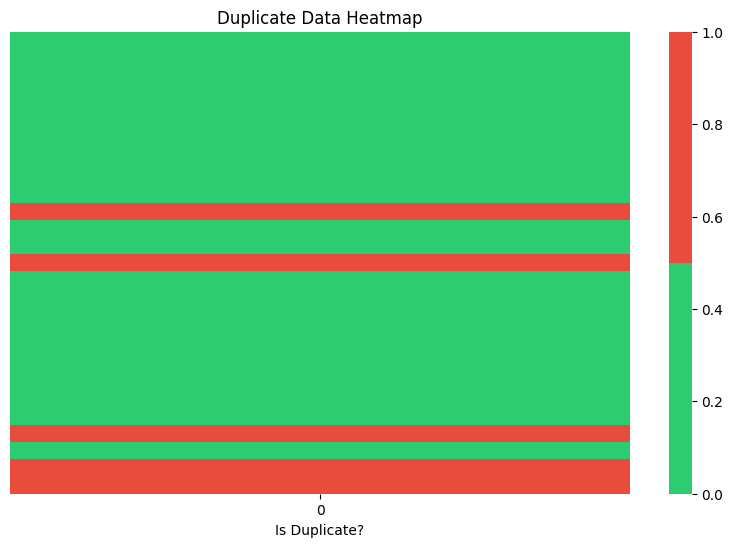

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load the data
df = pd.read_csv('02_duplicates.csv')

# Use df.duplicated() and convert to a frame so heatmap can plot it
# We use a boolean map: Green (False/Unique) vs Red (True/Duplicate)
plt.figure(figsize=(10,6))
sns.heatmap(df.duplicated().to_frame(), cmap=['#2ECC71','#E74C3C'],
            cbar=True, yticklabels=False)
plt.title("Duplicate Data Heatmap")
plt.xlabel("Is Duplicate?")
plt.show()


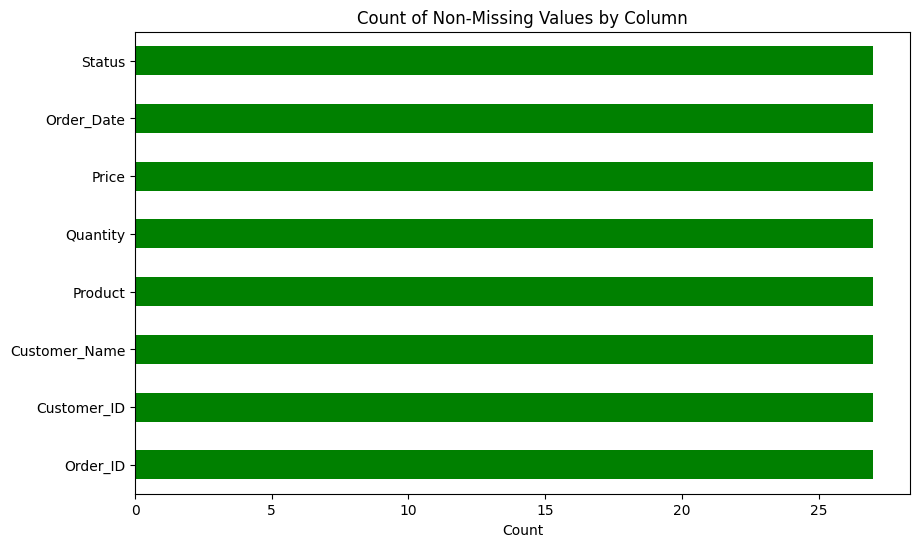

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('02_duplicates.csv')

# Plotting the count of non-null (existing) values
df.notnull().sum().sort_values(ascending=True).plot(
    kind='barh', figsize=(10,6), color='green'
)
plt.title("Count of Non-Missing Values by Column")
plt.xlabel("Count")
plt.show()


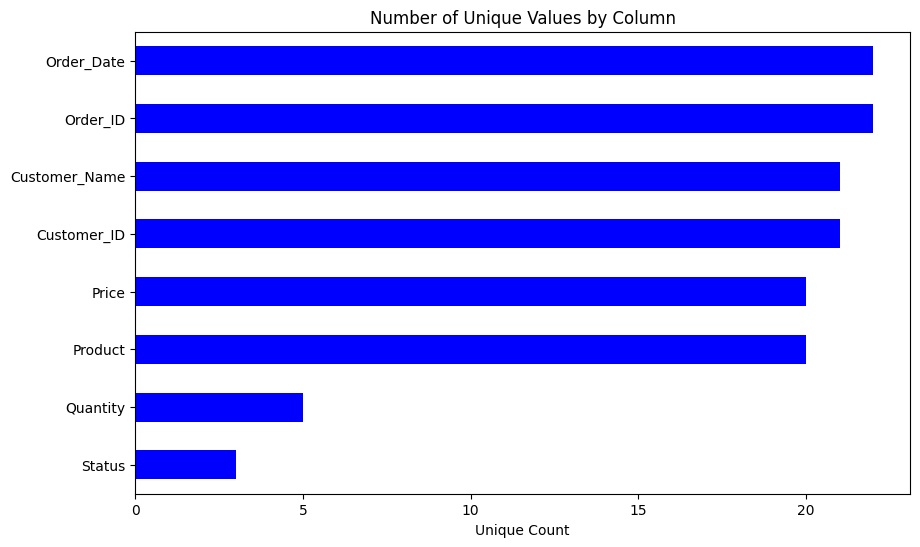

In [18]:
# Plotting the number of unique values in each column
df.nunique().sort_values(ascending=True).plot(
    kind='barh', figsize=(10,6), color='blue'
)
plt.title("Number of Unique Values by Column")
plt.xlabel("Unique Count")
plt.show()

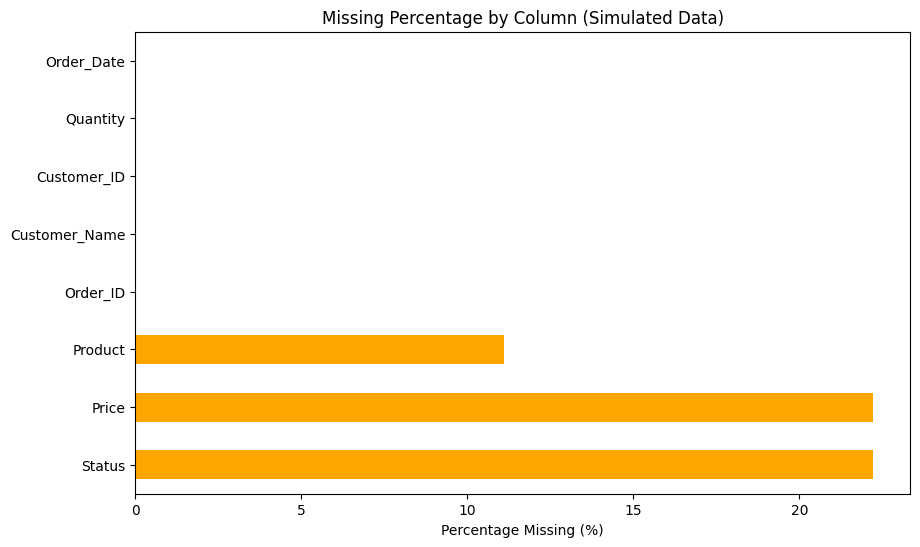

In [21]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# Load original data
df = pd.read_csv('02_duplicates.csv')

# Create a copy and introduce fake missing values for demonstration
df_missing = df.copy()
df_missing.loc[0:5, 'Price'] = np.nan       # Make 6 Prices missing
df_missing.loc[10:15, 'Status'] = np.nan    # Make 6 Statuses missing
df_missing.loc[0:2, 'Product'] = np.nan     # Make 3 Products missing

# NOW run your code on this modified dataframe
plt.figure()
(df_missing.isnull().sum()/len(df_missing)*100).sort_values(ascending=False).plot(
    kind='barh', figsize=(10,6), color='orange')
plt.title("Missing Percentage by Column (Simulated Data)")
plt.xlabel("Percentage Missing (%)")
plt.show()


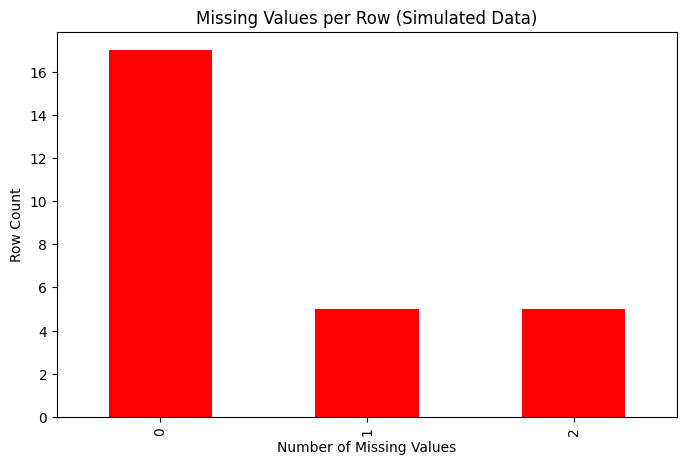

In [20]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('02_duplicates.csv')

# Create a copy and artificially delete data
df_missing = df.copy()
# Remove 'Price' from first 5 rows (1 missing per row)
df_missing.loc[0:4, 'Price'] = np.nan
# Remove 'Price' AND 'Status' from next 5 rows (2 missing per row)
df_missing.loc[5:9, ['Price', 'Status']] = np.nan

# Plotting the simulated dirty data
plt.figure(figsize=(8,5))
df_missing.isnull().sum(axis=1).value_counts().sort_index().plot(
    kind='bar', color='red')
plt.title("Missing Values per Row (Simulated Data)")
plt.xlabel("Number of Missing Values")
plt.ylabel("Row Count")
plt.show()


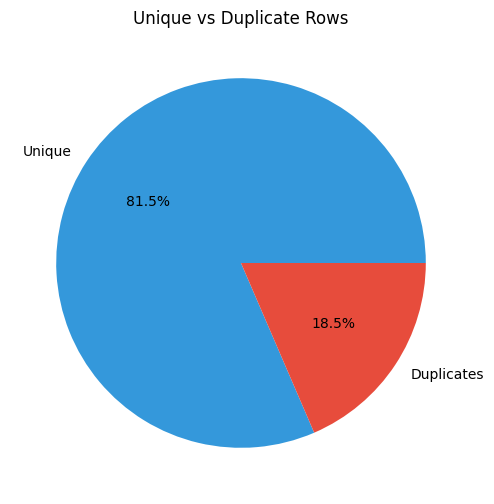

In [22]:
# import matplotlib.pyplot as plt
# import pandas as pd

df = pd.read_csv('02_duplicates.csv')

# Calculate Unique vs Duplicates
duplicate_count = df.duplicated().sum()
unique_count = len(df) - duplicate_count

# Plot
plt.figure(figsize=(6,6))
plt.pie([unique_count, duplicate_count],
        labels=['Unique', 'Duplicates'],
        autopct='%1.1f%%',
        colors=['#3498DB', '#E74C3C']) # Blue for Unique, Red for Duplicates
plt.title("Unique vs Duplicate Rows")
plt.show()


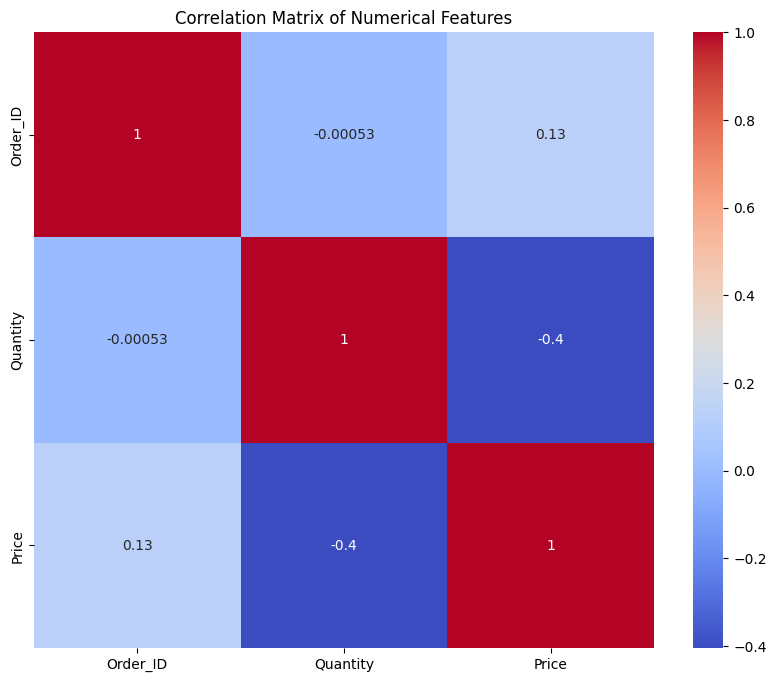

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('02_duplicates.csv')

# Select only numeric columns (Correlation only works on numbers)
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
# Calculate correlation on the ACTUAL data, not isnull()
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Numerical Features")
plt.show()


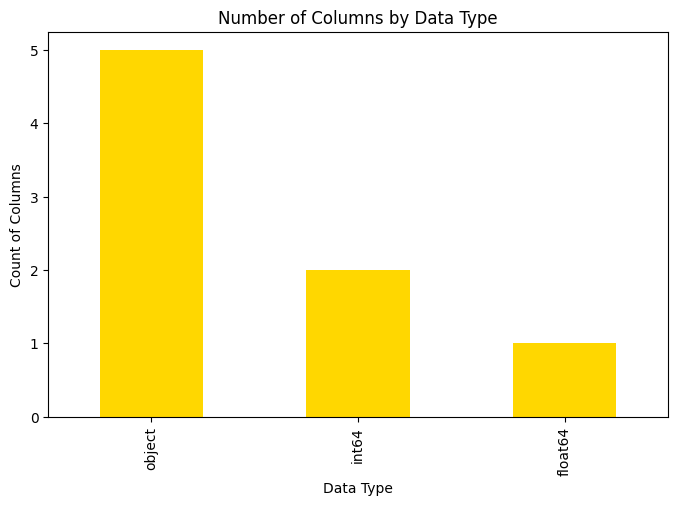

In [25]:
# import matplotlib.pyplot as plt
# import pandas as pd

# Load data
df = pd.read_csv('02_duplicates.csv')

# Plot the number of columns for each data type
plt.figure(figsize=(8,5))
df.dtypes.value_counts().plot(kind='bar', color='gold')
plt.title("Number of Columns by Data Type")
plt.xlabel("Data Type")
plt.ylabel("Count of Columns")
plt.show()

In [26]:
df_simple = df.copy()

# The original DataFrame 'df' does not contain columns like 'First_Name', 'Last_Name', 'Email', 'Phone',
# 'Department', 'Manager_ID', 'Office_Location', 'Salary', 'Years_Experience', or 'Hire_Date'.
# Also, the initial analysis showed that 'df' has no missing values.
# Therefore, the following lines attempting to fill NaNs in these non-existent columns are removed to resolve the KeyError.

print("Remaining Missing:", df_simple.isnull().sum().sum())
df_simple

Remaining Missing: 0


,Order_ID,Customer_ID,Customer_Name,Product,Quantity,Price,Order_Date,Status
0,1001,C001,John Smith,Laptop,1,1200.0,2023-01-15,Completed
1,1002,C002,Sarah Johnson,Mouse,2,25.0,2023-01-16,Completed
2,1003,C003,Mike Williams,Keyboard,1,75.0,2023-01-17,Pending
3,1004,C004,Emma Brown,Monitor,1,350.0,2023-01-18,Shipped
4,1005,C005,David Jones,Headphones,3,80.0,2023-01-19,Completed
5,1006,C006,Lisa Garcia,Webcam,1,120.0,2023-01-20,Pending
6,1007,C007,Robert Miller,Speaker,2,150.0,2023-01-21,Shipped
7,1008,C008,Jennifer Davis,USB Cable,5,10.0,2023-01-22,Completed
8,1009,C009,William Rodriguez,HDMI Cable,2,15.0,2023-01-23,Pending
9,1010,C010,Mary Martinez,Printer,1,250.0,2023-01-24,Shipped


In [27]:
# import pandas as pd
# import numpy as np

# Load Data
df = pd.read_csv('02_duplicates.csv')

# --- STEP 1: Simulate Missing Data (So the code actually does something) ---
df_demo = df.copy()
# Make row 0 missing 'Price'
df_demo.loc[0, 'Price'] = np.nan
# Make row 1 missing 'Product'
df_demo.loc[1, 'Product'] = np.nan
# Make row 2 missing 5 values (It will fail the threshold check)
df_demo.loc[2, ['Price', 'Product', 'Status', 'Order_Date', 'Customer_ID']] = np.nan

# --- STEP 2: The Corrected Logic ---

# 1. Drop All: Removes the row if ANY column is missing
df_drop_all = df_demo.dropna()

# 2. Drop Critical: Only removes the row if specific important columns are missing
# (Replaced 'Employee_ID', etc. with valid columns)
df_drop_critical = df_demo.dropna(subset=['Customer_ID', 'Product', 'Price'])

# 3. Drop Threshold: Keep row only if it has at least X non-missing values
# Your dataset has 8 columns. thresh=6 means "Keep if 6+ columns are valid"
df_drop_threshold = df_demo.dropna(thresh=6)

# --- STEP 3: Print Results ---
print(f"Original Rows: {len(df)}")
print(f"Drop All (Any Missing): {len(df_drop_all)} rows remaining")
print(f"Drop Critical (Subset): {len(df_drop_critical)} rows remaining")
print(f"Threshold Based (Keep if 6+ valid): {len(df_drop_threshold)} rows remaining")


Original Rows: 27
Drop All (Any Missing): 24 rows remaining
Drop Critical (Subset): 24 rows remaining
Threshold Based (Keep if 6+ valid): 26 rows remaining


In [28]:
# import pandas as pd
# import numpy as np

# Load data
df = pd.read_csv('02_duplicates.csv')

# --- Step 1: Create a copy and Simulate Missing Data ---
# (We do this because the original file has 0 missing values)
df_stats = df.copy()
df_stats.loc[0:4, 'Price'] = np.nan       # Simulate missing 'Salary'
df_stats.loc[5:9, 'Quantity'] = np.nan    # Simulate missing 'Years_Experience'
df_stats.loc[10:14, 'Status'] = np.nan    # Simulate missing categorical data
df_stats.loc[15:19, 'Product'] = np.nan   # Simulate missing categorical data

print("Missing before imputation:\n", df_stats.isnull().sum())
print("-" * 30)

# --- Step 2: Corrected Imputation Logic ---

# 1. Fill Numerical Column 1 (Price/Salary) with Median
df_stats['Price'] = df_stats['Price'].fillna(df_stats['Price'].median())

# 2. Fill Numerical Column 2 (Quantity/Experience) with Mean
df_stats['Quantity'] = df_stats['Quantity'].fillna(df_stats['Quantity'].mean())

# 3. Fill Categorical Columns with Mode
# Replacing 'First_Name', 'Department' etc. with actual columns 'Status', 'Product'
categorical_cols = ['Status', 'Product']

for col in categorical_cols:
    # mode() returns a Series, so we grab the first element [0]
    if not df_stats[col].mode().empty:
        mode_val = df_stats[col].mode()[0]
        df_stats[col] = df_stats[col].fillna(mode_val)

# --- Step 3: Result ---
print("Remaining Missing:", df_stats.isnull().sum().sum())
print("Missing after imputation:\n", df_stats.isnull().sum())


Missing before imputation:
 Order_ID         0
Customer_ID      0
Customer_Name    0
Product          5
Quantity         5
Price            5
Order_Date       0
Status           5
dtype: int64
------------------------------
Remaining Missing: 0
Missing after imputation:
 Order_ID         0
Customer_ID      0
Customer_Name    0
Product          0
Quantity         0
Price            0
Order_Date       0
Status           0
dtype: int64


In [29]:
# import pandas as pd
# import numpy as np

# Load Data
df = pd.read_csv('02_duplicates.csv')

# --- Step 1: Simulate Missing Data (So the code has work to do) ---
df_group = df.copy()
df_group.loc[0:5, 'Price'] = np.nan       # Missing Prices
df_group.loc[10:15, 'Quantity'] = np.nan  # Missing Quantities

print("Missing Before:\n", df_group[['Price', 'Quantity']].isnull().sum())
print("-" * 30)

# --- Step 2: The Logic ---

# 1. Fill missing Price (Salary) with the Median of its Status group
df_group['Price'] = df_group.groupby('Status')['Price']\
    .transform(lambda x: x.fillna(x.median()))

# Fallback: If a whole group was NaN, fill with global median
df_group['Price'] = df_group['Price'].fillna(df_group['Price'].median())

# 2. Fill missing Quantity (Experience) with the Mean of its Status group
df_group['Quantity'] = df_group.groupby('Status')['Quantity']\
    .transform(lambda x: x.fillna(x.mean()))

# Fallback
df_group['Quantity'] = df_group['Quantity'].fillna(df_group['Quantity'].mean())

# --- Step 3: Result ---
print("Remaining Missing Numeric:",
      df_group[['Price', 'Quantity']].isnull().sum().sum())


Missing Before:
 Price       6
Quantity    6
dtype: int64
------------------------------
Remaining Missing Numeric: 0
